In [2]:
from typing import List, Dict,  Union
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from ccxt.binance import binance
from ccxt.base.exchange import Exchange

from siglab_py.util.market_data_util import fetch_candles
from siglab_py.util.analytic_util import compute_volume_profile

### Fetch candles

In [3]:
start_date : datetime = datetime(2026,1,1)
end_date : datetime = datetime(2026,2,28)

param = {
    'apiKey' : None,
    'secret' : None,
    'password' : None,
    'subaccount' : None,
    'rateLimit' : 100,    # In ms
    'options' : {
        'defaultType': 'swap'            }
}

exchange : Exchange = binance(param) # type: ignore
normalized_symbols = [ 'BTC/USDT:USDT' ]
pd_candles: Union[pd.DataFrame, None] = fetch_candles(
    start_ts=start_date.timestamp(),
    end_ts=end_date.timestamp(),
    exchange=exchange,
    normalized_symbols=normalized_symbols,
    candle_size='1h'
)[normalized_symbols[0]]

assert pd_candles is not None

c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\market_data_util.py:316: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_rows_with_expected_gap = pd_candles[~pd_candles.timestamp_ms_gap.isna()][pd_candles.timestamp_ms_gap==timestamp_ms_gap_median].shape[0]


### Volume Profile

In [22]:
volume_profile = compute_volume_profile(
            pd_candles = pd_candles,
            level_granularity = 0.1, # i.e. 10%
            ohlc = 'close' # Compute volume profile from 'close' prices? Permissible values: open, high, low, close
        )
for x in volume_profile:
    bucket_key = x['bucket_key']
    volume = x['volume']
    local_maxima = x['local_maxima']
    if local_maxima:
        point_of_control = f'{bucket_key} volume: {int(volume):,}'
        print(point_of_control)


64000 - 68000 volume: 2,580,143
76000 - 80000 volume: 786,941
88000 - 92000 volume: 1,921,273


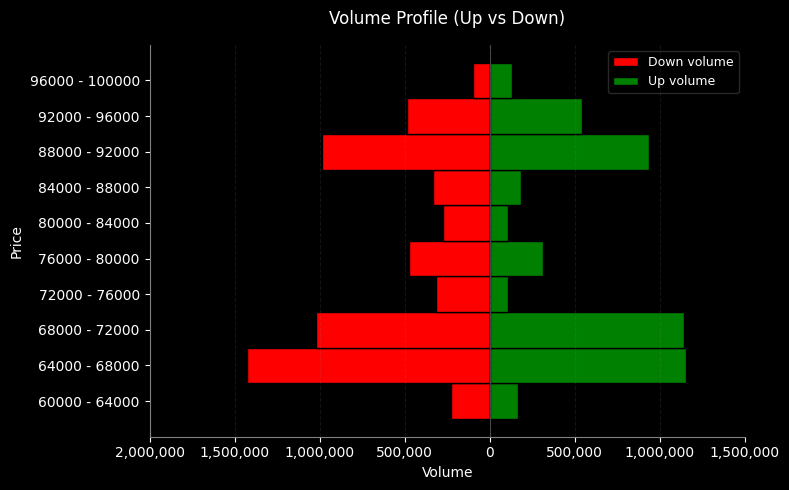

In [23]:
plt.style.use('dark_background')

bins = list(reversed([x['bucket_key'] for x in volume_profile]))
up_volumes = list(reversed([x['up_volume'] for x in volume_profile]))
down_volumes = list(reversed([x['down_volume'] for x in volume_profile]))

bins = bins[::-1]
up_volumes = up_volumes[::-1]
down_volumes = down_volumes[::-1]

plt.figure(figsize=(8, len(bins) * 0.5))

ax = plt.gca()

# down_volumes
ax.barh(
    y=bins,
    width=[-v for v in down_volumes],
    color='red',
    edgecolor='black',
    height=1,
    align='center',
    label='Down volume'
)

# up_volumes
ax.barh(
    y=bins,
    width=up_volumes,
    color='green',
    edgecolor='black',
    height=1,
    align='center',
    label='Up volume'
)

ax.set_xlabel('Volume', color='white')
ax.set_ylabel('Price', color='white')
ax.set_title('Volume Profile (Up vs Down)', color='white', pad=15)

ax.xaxis.set_tick_params(labelcolor='white')
ax.yaxis.set_tick_params(labelcolor='white')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([f'{int(abs(x)):,}' for x in ax.get_xticks()], color='white')

ax.grid(axis='x', alpha=0.15, linestyle='--', color='gray')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')

ax.axvline(0, color='gray', linewidth=0.8, alpha=0.5)

ax.legend(loc='upper right', fontsize=9, framealpha=0.2)

plt.tight_layout()
plt.show()